In [24]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [25]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

##### Görev 1
Kendi Value sınıfını yaz, toplama ve çarpma ile başla. Her yeni Value, kendisini üreten Value'ları ve hangi işlemden çıktığını saklasın. İstersen videodaki gibi computation graph'i graphviz ile çizdir. (19:09 - 32:10)

Bu görevde amacımız sonraki görevlerde kolaylık sağlaması için Value classımızı yazmak. Basit işlemleri yapmamızda ve görselleştirmemizzde yardımcı olacak. Kritik nokta geçmiş değerleri tutabilmesi, geçmiş değerleri tutulması ile geriyedönük işlemler yapabileceğiz backpropagation için.

bu kısımda manuel bir şekilde türevleri bulabiliriz.

In [26]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self.grad = 0
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value({self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out


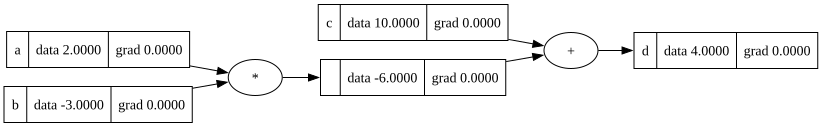

In [27]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')

d = a* b + c 
d.label='d'

draw_dot(d)

##### Görev 2
Otomatikleştirmeden önce gradient'leri videodaki iki örnekte elle doldur: önce basit ifade (32:10 - 51:10), sonra tek bir neuron. Neuron örneğinde tanh'ı Value'ya ekleyeceksin. Chain rule'u burada içselleştireceksin. (52:52 - 1:09:02)

(f(x+h) - f(x)) / h

gradyan check, zincir kuralı

bu kısımda amaç manuel bir şekilde türevleri adım adım bulmak ardından daha uzak noktalardaki örneğin aralarında 2 3 adım bulunan noktaların türevini bulabilmek. Zincir kuralı ile bu yapıyı kurarız. 

basitçe karpathynin örneği gibi:
insan = 2x 
bisiklet = 4 * insan        +
otobüs = 8 * bisiklet

basitçe kafamızda zincirleme yapıp otobüsün insandan 64x hızlı olduğunu görürüz.

işlemsel olarak bunları bilmekteyiz:
dL / dd
dd / dc

amacımız ise bunu bulabilmek:
dL / dc  yani =>  (dL / dd) x (dd / dc)

yani aslında otobüs ve insan arasındaki ilişkiyi görebilmek doğrudan sırayla yapmak yerine.

yerel türevler:

1. toplama işlemi: d = a + b
    burada a'yı 1 birim arttırırsam d de 1 birim artar yani d'nin a'ya türevi 1
    aynı şekilde b'yi 1 birim arttırırsam d de 1 birim artar yani d'nin b'ye türevi 1
    yani toplama işlemi gelen gradyanı olduğu gibi geriye iter (gradyan dağıtıcı, router)

2. çarpma işlemi: e = a x b
    a'yı 1 birim arttırırsam e, b kadar artar yani e'nin a'ya türevi b'dir
    b'yi 1 birim arttırırsam e, a kadar artar yani e'nin b'ye türevi a'dır
    yani çarpma işlemi girdilerin değerlerini çapraz olarak yer değiştirir (gradyan anahtarlayıcı, switcher)

3. tanh aktivasyonu: o = tanh(n)
     standart türev: do / dn = 1 -tanh^2(n) = 1 - o^2
     yani tanh'In çıktısını biliyorsak (o) türevi doğrudan 1 - o^2 olur
     



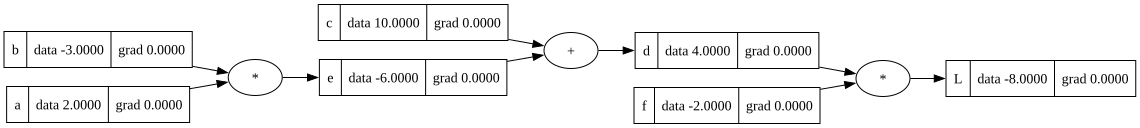

In [28]:
#manuel gradyanları atamak için örneğimiz, gradlarımız 0 gördüğünüz gibi

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b;             e.label = 'e'
d = e + c;             d.label = 'd'
f = Value(-2.0, label='f')
L = d * f;             L.label = 'L'

draw_dot(L)

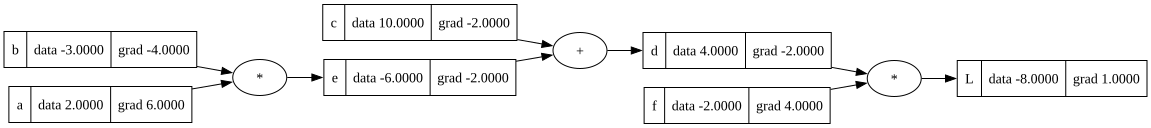

In [29]:
#örneğimize atamalarımı yaptığım kısımlar ve işlemlerim

# kendine göre türevden L'nin L'ye göre türevi her zaman 1'dir.
L.grad = 1.0

# L = d x f için :
# f nesnemiz için: dL/dd = d.data x L.grad = -2 x 4 = -2
d.grad = f.data * L.grad
# d nesnemiz için: dL /df = f.data x L.grad = -2 x 1 = -2
f.grad = d.data * L.grad


# d = e + c için:
# zincir kuralı uygularız, üstten d'ye gelen gradyan d.grad= -2'dir
# e'nin yerel türevi dd/de = 1dir
e.grad = 1.0 * d.grad # = -2

#c'nin yerel türevi dd/dc = 1dir
c.grad = 1.0 * d.grad # = -2



# e = a x b için:
#yine zincir kuralı
# üstten e'ye gelen gradye e.grad = -2dir
a.grad = b.data * e.grad # =6
b.grad = a.data * e.grad #-4

draw_dot(L)